# POD-NN for Parametric Navier-Stokes (with data normalisation)

**MODEL ORDER REDUCTION AND MACHINE LEARNING — Project A.Y. 2025/2026**

The POD-NN strategy replaces the ROM online solve with a single NN forward pass.  
The network maps $\boldsymbol\mu \mapsto \underline{u}_{\mathsf{rb}}(\boldsymbol\mu)$ directly.

**Why normalise?**  
- The two parameters live on very different scales: $\mu_0\in[0.1,10]$ vs $\mu_1\in[1,3]$.  
- The reduced coefficients $\underline{u}_{\mathsf{rb}}$ can vary by several orders of magnitude across modes.  
- Without normalisation the MSE loss is dominated by the largest-magnitude output components,
  gradients become unbalanced, and convergence stalls at a high loss value.  

**What we normalise:**
1. **Inputs** $\boldsymbol\mu$: min-max scaled to $[-1, +1]$ per parameter (matches Tanh output range).  
2. **Outputs** $\underline{u}_{\mathsf{rb}}$: standardised per component (zero mean, unit std) so every
   reduced coefficient contributes equally to the MSE.  

The scalers are fitted **only on the training set** and stored; they are applied in reverse during
the online phase before reconstructing the FE solution.

---

## Problem
$$
\begin{cases}
-\mu_0\,\nabla\cdot(\nabla\mathbf{u}) + (\nabla\mathbf{u})\mathbf{u} + \nabla p = \mathbf{f}(x;\mu_1)
& \text{in }\Omega=(0,1)^2\\
\nabla\cdot\mathbf{u}=0 & \text{in }\Omega\\
\mathbf{u}=0 & \text{on }\partial\Omega
\end{cases}
\qquad \boldsymbol\mu=(\mu_0,\mu_1)\in[0.1,10]\times[1,3]
$$

## Part 0 — Setup

In [43]:
import numpy as np
import os
import scipy.sparse
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn

from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

os.makedirs('./Export/POD_NN/Solution', exist_ok=True)

In [44]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities     = gedim.MeshUtilities()
vtk_utilities      = ExportVTKUtilities()

## Part 1 — Mesh and Taylor-Hood FE Space

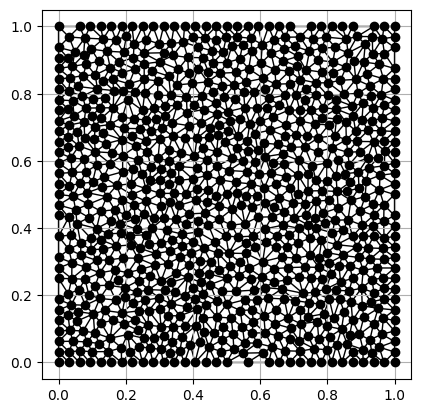

In [45]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                 [0.0, 0.0, 1.0, 1.0],
                                 [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = (
    polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram)
pde_domain.area = 1.0

mesh_type   = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size   = 0.001   # coarser for faster snapshot collection; refine as needed

mesh_data = gedim.MeshMatrices()
mesh      = gedim.MeshMatricesDAO(mesh_data)
polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(
    geometry_utilities, mesh_utilities, mesh_type, pde_domain, mesh_size, mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(
    geometry_utilities, mesh_utilities, mesh)

vtk_utilities.export_mesh('./Export/POD_NN', mesh)
other_ut.plot_mesh(mesh)

In [46]:
# Boundary conditions: u=0 on all borders, p=0 at point (0,0).
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal, 1: info_dirichlet,
    2: info_neumann_none, 3: info_neumann_none, 4: info_neumann_none,
    5: info_neumann_none, 6: info_neumann_none, 7: info_neumann_none, 8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet, 2: info_dirichlet, 3: info_dirichlet, 4: info_dirichlet,
    5: info_dirichlet, 6: info_dirichlet, 7: info_dirichlet, 8: info_dirichlet
}

# Taylor-Hood P2/P1 element.
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
    pressure_reference_element_data, mesh, pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
    speed_reference_element_data, mesh, speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, mesh_connectivity_data)

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs, "\t", pressure_n_strongs, "\t",
      speed_n_dofs, "\t", speed_n_strongs, "\t", tot_dofs, "\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


## Part 2 — FOM Solver (Newton's method)

In [47]:
# ── Problem functions ─────────────────────────────────────────────────────────
def f_x_function(x, y, z, mu):
    term1 = -(mu[1]**3 * np.pi**2 * np.cos(mu[1]**2 * np.pi * x)
              - mu[1]**2 * np.pi**2) \
            * np.sin(mu[1] * np.pi * y) * np.cos(mu[1] * np.pi * y)
    term2 = mu[1] * np.pi * np.cos(mu[1] * np.pi * x) * np.cos(mu[1] * np.pi * y)
    return term1 + term2

def f_y_function(x, y, z):              return np.zeros_like(x)
def pressure_strong_function(m, x, y, z): return np.zeros_like(x)
def speed_x_strong_function(m, x, y, z): return np.zeros_like(x)
def speed_y_strong_function(m, x, y, z): return np.zeros_like(x)
def speed_x_ic(x, y, z):               return 0.0
def speed_y_ic(x, y, z):               return 0.0
def pressure_ic(x, y, z):              return 0.0
def b_x_term(x, y, z):                 return np.array([1., 0., 0.])
def b_y_term(x, y, z):                 return np.array([0., 1., 0.])

In [48]:
def solve_ns(mu, newton_tol=1e-6, max_iter=10, verbose=False):
    """
    Full-order N-S solver via Newton's method.
    Returns [u_x | u_y | p] DOF vector.
    """
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: f_x_function(x, y, z, mu))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        f_y_function)
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_y_strong_function)

    A_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: mu[0])
    Bx_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_x_term)
    By_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_y_term)

    J_Ax  = other_ut.make_np_sparse(A_op.operator_dofs,  [tot_dofs, tot_dofs], [0, 0])
    J_Ay  = other_ut.make_np_sparse(A_op.operator_dofs,  [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    J_Bx  = other_ut.make_np_sparse(Bx_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
    J_By  = other_ut.make_np_sparse(By_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
    J_BTx = other_ut.make_np_sparse(Bx_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
    J_BTy = other_ut.make_np_sparse(By_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)
    J_S = J_Ax + J_Ay - J_Bx - J_By - J_BTx - J_BTy

    u_x_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_x_ic).function_dofs
    u_y_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_y_ic).function_dofs
    p_num   = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_dofs_data, pressure_reference_element_data, pressure_ic).function_dofs
    u_k = np.concatenate([u_x_num, u_y_num, p_num])

    du_x_s = np.zeros(speed_n_strongs)
    du_y_s = np.zeros(speed_n_strongs)
    dp_s   = np.zeros(pressure_n_strongs)
    res = 1.0;  sol = 1.0

    for it in range(1, max_iter + 1):
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_k[0:speed_n_dofs], u_k[speed_n_dofs:2*speed_n_dofs],
            u_x_strong, u_y_strong)
        J_C = other_ut.make_np_sparse(
            c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])

        du   = scipy.sparse.linalg.spsolve(J_S + J_C, f_S - f_C - J_S @ u_k)
        u_k += du

        du_x = du[0:speed_n_dofs]; du_y = du[speed_n_dofs:2*speed_n_dofs]; dp = du[2*speed_n_dofs:]
        u_x_num = u_k[0:speed_n_dofs]
        u_y_num = u_k[speed_n_dofs:2*speed_n_dofs]

        ex = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_x, du_x_s)
        ey = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_y, du_y_s)
        ep = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            pressure_dofs_data, pressure_reference_element_data, dp, dp_s)
        res = np.sqrt(ex.numeric_norm_l2**2 + ey.numeric_norm_l2**2 + ep.numeric_norm_l2**2)

        if verbose:
            print(f"  Newton {it}: |res|={res:.3e}")
        if res < newton_tol * max(sol, 1e-12):
            break

    return u_k

## Part 3 — Offline Phase: Snapshots and POD

In [49]:
# Parameter space.
mu0_range = [0.1, 10.0]
mu1_range = [1.0,  3.0]
P = np.array([mu0_range, mu1_range])

snapshot_num = 200
np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1],
                                  size=(snapshot_num, P.shape[0]))
print(f"Training set: {snapshot_num} samples  |  mu0 in {mu0_range}  |  mu1 in {mu1_range}")

Training set: 200 samples  |  mu0 in [0.1, 10.0]  |  mu1 in [1.0, 3.0]


In [50]:
# Reference operators for inner products (assembled once with mu0=1).
A_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, speed_dofs_data,
    speed_reference_element_data, speed_reference_element_data,
    lambda x, y, z: 1.0)
Bx_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_x_term)
By_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_y_term)

X_1 = other_ut.make_np_sparse(A_ref.operator_dofs, [2*speed_n_dofs, 2*speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_ref.operator_dofs, [2*speed_n_dofs, 2*speed_n_dofs],
                               [speed_n_dofs, speed_n_dofs])
inner_product_u = X_1 + X_2   # H1 semi-norm for velocity

B_1 = other_ut.make_np_sparse(Bx_ref.operator_dofs, [pressure_n_dofs, 2*speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(By_ref.operator_dofs, [pressure_n_dofs, 2*speed_n_dofs],
                               [0, speed_n_dofs])
print("Inner product matrices assembled.")

Inner product matrices assembled.


In [51]:
snapshot_matrix_u, snapshot_matrix_s, snapshot_matrix_p = [], [], []
tol_pod = 1. - 1e-7
N_max   = 20

print("Collecting FOM snapshots...")
for it, mu in enumerate(training_set):
    if it % 20 == 0:
        print(f"  {it}/{snapshot_num}  mu0={mu[0]:.2f}  mu1={mu[1]:.2f}")
    u_k  = solve_ns(mu)
    su   = u_k[0:2*speed_n_dofs]
    sp   = u_k[2*speed_n_dofs:]
    ss   = scipy.sparse.linalg.spsolve(X_1 + X_2, (B_1 + B_2).T @ sp)
    snapshot_matrix_u.append(np.copy(su))
    snapshot_matrix_s.append(np.copy(ss))
    snapshot_matrix_p.append(np.copy(sp))

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)
print(f"Snapshots collected. Shapes: u={snapshot_matrix_u.shape}, p={snapshot_matrix_p.shape}")

  0/200  mu0=5.53  mu1=2.43
  20/200  mu0=3.66  mu1=1.87
  40/200  mu0=3.25  mu1=1.83
  60/200  mu0=7.28  mu1=2.00
  80/200  mu0=7.00  mu1=1.91
  100/200  mu0=3.19  mu1=2.39
  120/200  mu0=8.65  mu1=1.24
  140/200  mu0=3.00  mu1=2.70
  160/200  mu0=2.78  mu1=1.26
  180/200  mu0=1.95  mu1=2.81
Snapshots collected. Shapes: u=(200, 5932), p=(200, 829)


In [52]:
def eig_analysis(C, N_max=None, tol=1e-9):
    L, V = np.linalg.eig(C)
    eigs, vecs = [], []
    for i in range(len(L)):
        assert np.isclose(L[i].imag, 0.)
        eigs.append(L[i].real);  vecs.append(V[i].real)
    retained = np.cumsum(eigs) / sum(eigs)
    if N_max is not None and all(r < tol for r in retained):
        N = N_max
    else:
        N = int(np.argmax(retained >= tol)) + 1
    return N, vecs, retained

def build_basis(N, snapshots, eigvecs, inner_product=None):
    basis = []
    for n in range(N):
        b = snapshots.T @ eigvecs[n]
        norm = np.sqrt(b @ (inner_product @ b) if inner_product is not None else b @ b)
        basis.append(b / norm)
    return np.array(basis).T   # shape (n_dofs, N)

C_u = snapshot_matrix_u @ inner_product_u @ snapshot_matrix_u.T
C_s = snapshot_matrix_s @ inner_product_u @ snapshot_matrix_s.T
C_p = snapshot_matrix_p @ snapshot_matrix_p.T

N_u, eigs_u, ret_u = eig_analysis(C_u, N_max=N_max, tol=tol_pod)
N_s, eigs_s, ret_s = eig_analysis(C_s, N_max=N_max, tol=tol_pod)
N_p, eigs_p, ret_p = eig_analysis(C_p, N_max=N_max, tol=tol_pod)
print(f"POD dimensions — N_u: {N_u},  N_s: {N_s},  N_p: {N_p}  (total: {N_u+N_s+N_p})")


POD dimensions — N_u: 22,  N_s: 27,  N_p: 24  (total: 73)


In [53]:
bf_u = build_basis(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
bf_s = build_basis(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
bf_p = build_basis(N_p, snapshot_matrix_p, eigs_p)

N_tot  = N_u + N_s + N_p
size_u = bf_u.shape[0]   # 2 * speed_n_dofs
size_p = bf_p.shape[0]   # pressure_n_dofs

global_basis = np.zeros((size_u + size_p, N_tot))
global_basis[0:size_u, 0:N_u]          = bf_u
global_basis[0:size_u, N_u:N_u+N_s]   = bf_s
global_basis[size_u:,  N_u+N_s:]       = bf_p
print(f"Global basis shape: {global_basis.shape}")

Global basis shape: (6761, 73)


## Part 4 — Build Training Data and Normalise

### Why normalise and how

Two independent normalisations are applied:

**Input scaler** — min-max to $[-1,+1]$ per parameter:
$$
\tilde{\mu}_i = 2\,\frac{\mu_i - \mu_i^{\min}}{\mu_i^{\max} - \mu_i^{\min}} - 1
$$
This maps the training range exactly onto $[-1,+1]$, which matches the
saturation-free region of the `Tanh` activations and prevents one parameter from dominating.

**Output scaler** — standardisation (z-score) per reduced coordinate:
$$
\tilde{u}_{\mathsf{rb},k} = \frac{u_{\mathsf{rb},k} - \bar{u}_{\mathsf{rb},k}}{\sigma_k}
$$
The POD coefficients for different modes can differ by orders of magnitude; without this
the MSE loss is dominated by the few large-variance modes and the NN ignores the small ones.
After standardisation every mode contributes equally.

Both scalers are fitted on the training set only and stored so they can be inverted at test time.

In [54]:
# ── Galerkin projection coefficients (raw) ────────────────────────────────────
B_vel = global_basis[0:size_u, 0:N_u+N_s]
B_prs = global_basis[size_u:,  N_u+N_s:]
X_N_vel = B_vel.T @ inner_product_u @ B_vel
X_N_prs = B_prs.T @ B_prs

coeffs_raw = []   # (N_snap, N_tot)
for i in range(snapshot_num):
    cv = np.linalg.solve(X_N_vel, B_vel.T @ (inner_product_u @ snapshot_matrix_u[i]))
    cp = np.linalg.solve(X_N_prs, B_prs.T @ snapshot_matrix_p[i])
    coeffs_raw.append(np.concatenate([cv, cp]))
coeffs_raw = np.array(coeffs_raw)   # (N_snap, N_tot)

# ── Input scaler: min-max → [-1, +1] ─────────────────────────────────────────
mu_min  = training_set.min(axis=0)   # shape (2,)
mu_max  = training_set.max(axis=0)
mu_rng  = mu_max - mu_min

def scale_input(mu):
    """Map raw parameter array (N, 2) or (2,) to [-1, +1]."""
    return 2.0 * (np.array(mu) - mu_min) / mu_rng - 1.0

# ── Output scaler: z-score per reduced coordinate ─────────────────────────────
coeff_mean = coeffs_raw.mean(axis=0)   # (N_tot,)
coeff_std  = coeffs_raw.std(axis=0)    # (N_tot,)
# Guard against zero std (constant mode).
coeff_std  = np.where(coeff_std < 1e-12, 1.0, coeff_std)

def scale_output(c):
    """Standardise raw coefficients."""
    return (c - coeff_mean) / coeff_std

def unscale_output(c_norm):
    """Inverse transform: recover raw coefficients from standardised ones."""
    return c_norm * coeff_std + coeff_mean

# ── Normalised training tensors ───────────────────────────────────────────────
X_train_np = np.float32(scale_input(training_set))       # (N_snap, 2)
Y_train_np = np.float32(scale_output(coeffs_raw))        # (N_snap, N_tot)

x_train = torch.tensor(X_train_np)
y_train = torch.tensor(Y_train_np)

print(f"Normalised input  range: [{X_train_np.min():.3f}, {X_train_np.max():.3f}]  (target [-1,+1])")
print(f"Normalised output mean:  {Y_train_np.mean():.4f}  std: {Y_train_np.std():.4f}  (target 0, 1)")
print(f"\nInput shape : {x_train.shape}")
print(f"Output shape: {y_train.shape}")


Normalised input  range: [-1.000, 1.000]  (target [-1,+1])
Normalised output mean:  0.0000  std: 1.0000  (target 0, 1)

Input shape : torch.Size([200, 2])
Output shape: torch.Size([200, 73])


## Part 5 — Define and Train the Neural Network

Architecture: $\mathbb{R}^2 \xrightarrow{\text{scaled}} \text{FC}_{64}^4 \to \mathbb{R}^{N_{\text{tot}}}$.  
The network operates entirely in normalised space; the inverse scaler is applied only at prediction time.

In [55]:
class Net(nn.Module):
    def __init__(self, in_dim, out_dim, nodes=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, nodes), nn.Tanh(),
            nn.Linear(nodes, nodes),  nn.Tanh(),
            nn.Linear(nodes, nodes),  nn.Tanh(),
            nn.Linear(nodes, nodes),  nn.Tanh(),
            nn.Linear(nodes, out_dim)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
torch.set_default_dtype(torch.float32)

net       = Net(P.shape[0], N_tot)
loss_fn   = nn.MSELoss()

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in net.parameters())
print(net)
print(f"Trainable parameters: {n_params}")

Net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=73, bias=True)
  )
)
Trainable parameters: 59337


In [56]:
'''
epoch_max    = 200000
train_tol    = 1e-5
loss_history = []
epoch = 0;  loss_val = 1.0

# Learning-rate schedule.
lr_schedule = {50000: 5e-4, 100000: 1e-4, 150000: 5e-5}

print("Training POD-NN (normalised)...")
while loss_val >= train_tol and epoch < epoch_max:
    epoch += 1
    optimizer.zero_grad()

    pred     = net(x_train)
    loss     = loss_fn(pred, y_train)
    loss_val = loss.item()

    if epoch in lr_schedule:
        optimizer.param_groups[0]['lr'] = lr_schedule[epoch]

    loss.backward()
    optimizer.step()
    loss_history.append(loss_val)

    if epoch % 5000 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"  epoch {epoch:>7d}  loss {loss_val:.6e}  lr {lr:.1e}")

print(f"\nTraining done — epoch {epoch},  final loss {loss_val:.6e}")
'''
'''
# Inizializziamo lo scheduler per abbattere le oscillazioni (il "bouncing")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,       # Dimezza il learning rate...
    patience=500,    # ...se la loss non scende per 2000 epoche
    min_lr=1e-6       # Soglia minima per non fermare del tutto l'apprendimento
)
'''
epoch_max    = 200000
train_tol    = 1e-5
loss_history = []
epoch = 0;  loss_val = 1.0

print("Training POD-NN (normalised)...")
while loss_val >= train_tol and epoch < epoch_max:
    epoch += 1
    optimizer.zero_grad()

    pred     = net(x_train)
    loss     = loss_fn(pred, y_train)
    loss_val = loss.item()

   
    
    # Lo scheduler osserva la loss corrente e decide se tagliare il Learning Rate
    #scheduler.step(loss_val)
    
    loss_history.append(loss_val)

    #if epoch % 5000 == 0:
        # Estraiamo il learning rate corrente per stamparlo e monitorarlo
        #lr = optimizer.param_groups[0]['lr']
        #print(f"  epoch {epoch:>7d}  loss {loss_val:.6e}  lr {lr:.1e}")

    if epoch >= 20000:
        optimizer.param_groups[0]['lr'] = 0.0001  

    loss.backward()
    optimizer.step()
    
    if (epoch % 2000) == 0:
        print("epoch", epoch, 'loss', loss.item(), 'lr', optimizer.param_groups[0]['lr'] )

print(f"\nTraining done — epoch {epoch},  final loss {loss_val:.6e}")

'''
while loss_val >= tol and epoch < epoch_max:
  epoch = epoch + 1
  optimizer.zero_grad()
          
  pred     = net(x_train)
  loss     = loss_fn(pred, y_train)
  loss_val = loss.item()
  if epoch >= 20000:
    optimizer.param_groups[0]['lr'] = 0.0001  
  #compute the gradients
  loss.backward()
  # optimizer update
  optimizer.step()
  loss_history.append(loss_val)
  if (epoch % 2000) == 0:
    print("epoch", epoch, 'loss', loss.item(), 'lr', optimizer.param_groups[0]['lr'] )
 '''             

Training POD-NN (normalised)...
epoch 2000 loss 0.002269054064527154 lr 0.001
epoch 4000 loss 0.0009499259758740664 lr 0.001
epoch 6000 loss 0.0006722845719195902 lr 0.001
epoch 8000 loss 0.00043932104017585516 lr 0.001
epoch 10000 loss 0.0004617811646312475 lr 0.001
epoch 12000 loss 0.0002887353184632957 lr 0.001
epoch 14000 loss 0.0002664539497345686 lr 0.001
epoch 16000 loss 0.00036834858474321663 lr 0.001
epoch 18000 loss 0.00015324050036724657 lr 0.001
epoch 20000 loss 0.00012797446106560528 lr 0.0001
epoch 22000 loss 0.00011343525693519041 lr 0.0001
epoch 24000 loss 9.922561002895236e-05 lr 0.0001
epoch 26000 loss 8.178505959222093e-05 lr 0.0001
epoch 28000 loss 6.611896242247894e-05 lr 0.0001
epoch 30000 loss 5.578823765972629e-05 lr 0.0001
epoch 32000 loss 5.096629320178181e-05 lr 0.0001
epoch 34000 loss 4.28449893661309e-05 lr 0.0001
epoch 36000 loss 3.7311863707145676e-05 lr 0.0001
epoch 38000 loss 3.357312016305514e-05 lr 0.0001
epoch 40000 loss 3.0929644708521664e-05 lr 0.0

'\nwhile loss_val >= tol and epoch < epoch_max:\n  epoch = epoch + 1\n  optimizer.zero_grad()\n\n  pred     = net(x_train)\n  loss     = loss_fn(pred, y_train)\n  loss_val = loss.item()\n  if epoch >= 20000:\n    optimizer.param_groups[0][\'lr\'] = 0.0001  \n  #compute the gradients\n  loss.backward()\n  # optimizer update\n  optimizer.step()\n  loss_history.append(loss_val)\n  if (epoch % 2000) == 0:\n    print("epoch", epoch, \'loss\', loss.item(), \'lr\', optimizer.param_groups[0][\'lr\'] )\n '

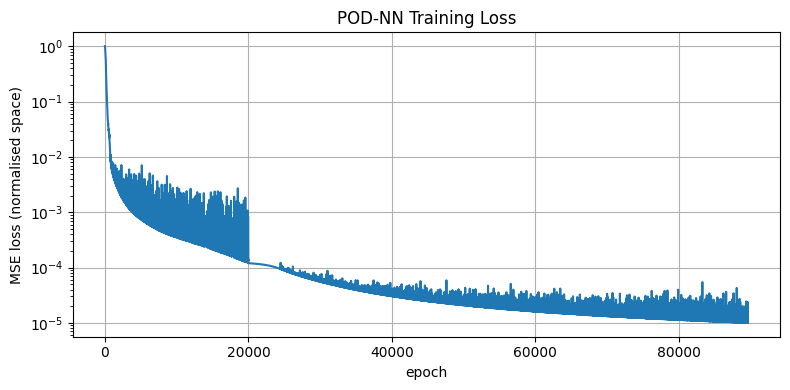

In [57]:
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history)
plt.xlabel('epoch'); plt.ylabel('MSE loss (normalised space)')
plt.title('POD-NN Training Loss')
plt.grid(True); plt.tight_layout(); plt.show()

In [58]:
'''
import numpy as np

# 1. Prendiamo il primissimo parametro usato nel training
idx = 0
mu_known = training_set[idx]

print(f"--- TEST DIAGNOSTICO SU PUNTO NOTO: mu = {mu_known} ---")

# 2. Facciamo la predizione con la rete
nn_sol_known = predict_podnn(mu_known)
nn_u_x_known = nn_sol_known[0:speed_n_dofs]
nn_u_y_known = nn_sol_known[speed_n_dofs:2*speed_n_dofs]
nn_p_known   = nn_sol_known[2*speed_n_dofs:]

# 3. Prendiamo la soluzione esatta (lo snapshot che avevi già calcolato!)
exact_u_known = snapshot_matrix_u[idx]
exact_p_known = snapshot_matrix_p[idx]

exact_u_x = exact_u_known[0:speed_n_dofs]
exact_u_y = exact_u_known[speed_n_dofs:2*speed_n_dofs]

# 4. Calcoliamo l'errore relativo L2 vettoriale nudo e crudo
err_rel_ux = np.linalg.norm(nn_u_x_known - exact_u_x) / np.linalg.norm(exact_u_x)
err_rel_uy = np.linalg.norm(nn_u_y_known - exact_u_y) / np.linalg.norm(exact_u_y)
err_rel_p  = np.linalg.norm(nn_p_known - exact_p_known) / np.linalg.norm(exact_p_known)

print(f"Errore Relativo u_x sul Training Set : {err_rel_ux:.4e}")
print(f"Errore Relativo u_y sul Training Set : {err_rel_uy:.4e}")
print(f"Errore Relativo Pressione sul Train  : {err_rel_p:.4e}")
'''

'\nimport numpy as np\n\n# 1. Prendiamo il primissimo parametro usato nel training\nidx = 0\nmu_known = training_set[idx]\n\nprint(f"--- TEST DIAGNOSTICO SU PUNTO NOTO: mu = {mu_known} ---")\n\n# 2. Facciamo la predizione con la rete\nnn_sol_known = predict_podnn(mu_known)\nnn_u_x_known = nn_sol_known[0:speed_n_dofs]\nnn_u_y_known = nn_sol_known[speed_n_dofs:2*speed_n_dofs]\nnn_p_known   = nn_sol_known[2*speed_n_dofs:]\n\n# 3. Prendiamo la soluzione esatta (lo snapshot che avevi già calcolato!)\nexact_u_known = snapshot_matrix_u[idx]\nexact_p_known = snapshot_matrix_p[idx]\n\nexact_u_x = exact_u_known[0:speed_n_dofs]\nexact_u_y = exact_u_known[speed_n_dofs:2*speed_n_dofs]\n\n# 4. Calcoliamo l\'errore relativo L2 vettoriale nudo e crudo\nerr_rel_ux = np.linalg.norm(nn_u_x_known - exact_u_x) / np.linalg.norm(exact_u_x)\nerr_rel_uy = np.linalg.norm(nn_u_y_known - exact_u_y) / np.linalg.norm(exact_u_y)\nerr_rel_p  = np.linalg.norm(nn_p_known - exact_p_known) / np.linalg.norm(exact_p_known)

## Part 6 — Online Phase: POD-NN Prediction

Online pipeline for a new $\boldsymbol\mu$:
1. Scale input: $\tilde{\boldsymbol\mu} = \text{scale\_input}(\boldsymbol\mu)$
2. NN forward pass: $\tilde{\underline{u}}_{\mathsf{rb}} = \pi(\tilde{\boldsymbol\mu})$
3. Inverse-scale output: $\underline{u}_{\mathsf{rb}} = \text{unscale\_output}(\tilde{\underline{u}}_{\mathsf{rb}})$
4. Reconstruct: $u_h = \mathbb{B}\,\underline{u}_{\mathsf{rb}}$

**No assembly. No linear solve.**

Testing with mu_test = [7.5, 2.5]
  Newton 1: |res|=4.804e+00
  Newton 2: |res|=1.222e-04
  Newton 3: |res|=7.022e-13

--- POD-NN ---


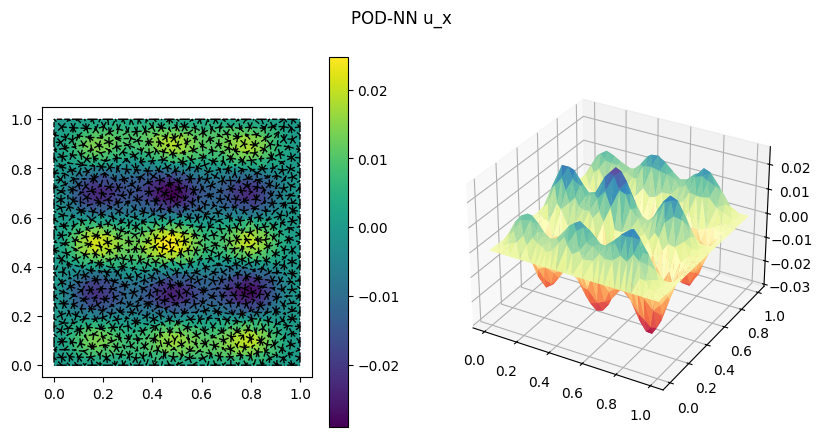

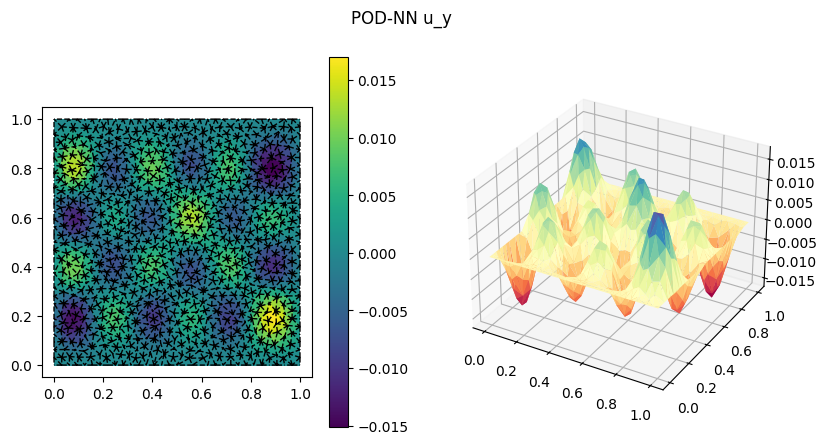

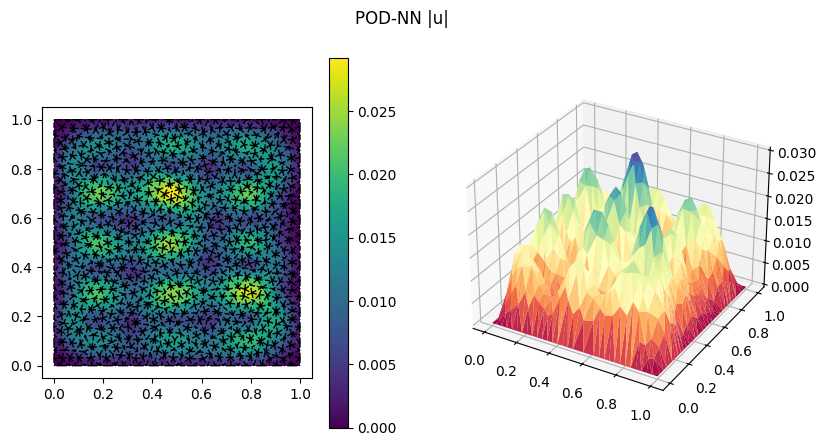


--- FOM ---


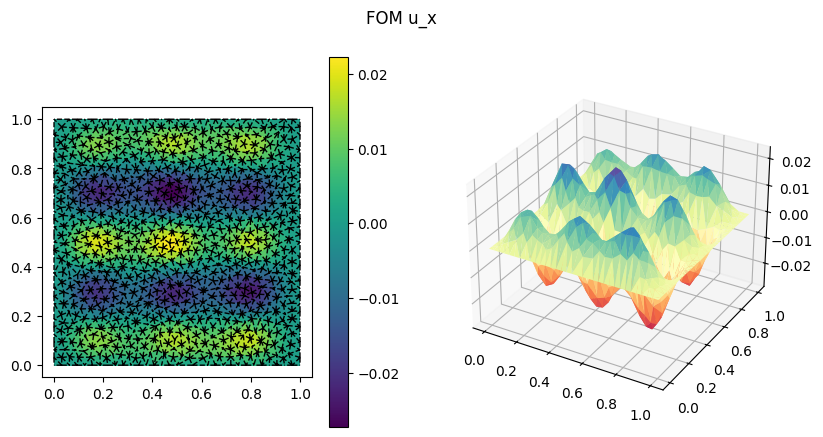

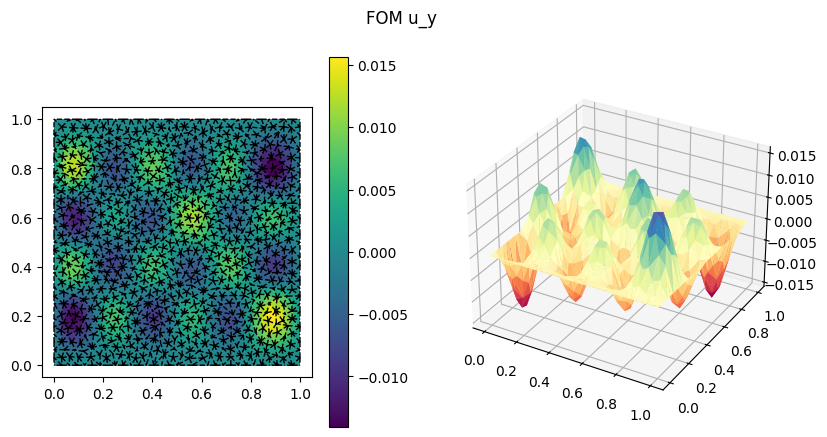

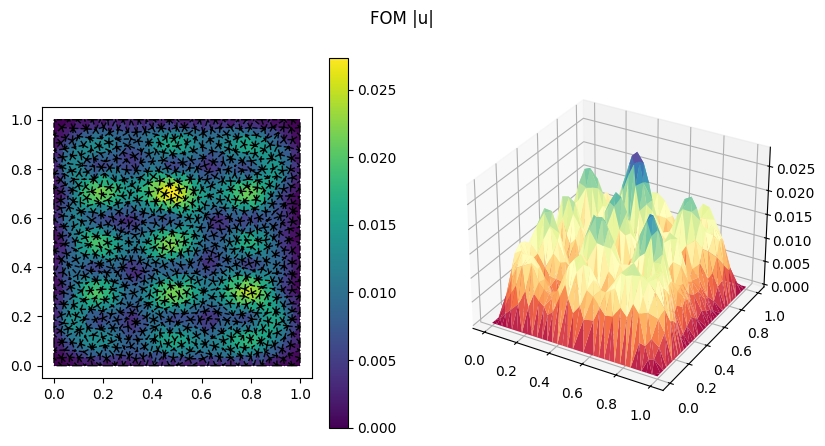

In [68]:
def predict_podnn(mu):
    """
    Online POD-NN prediction for a parameter vector mu.
    Returns the reconstructed FE solution vector [u_x | u_y | p].
    """
    mu_scaled = np.float32(scale_input(np.array(mu)))
    x_t = torch.tensor(mu_scaled[None, :])   # (1, 2)
    net.eval()
    with torch.no_grad():
        coeff_norm = net(x_t).numpy()[0]      # (N_tot,) — normalised space
    coeff = unscale_output(coeff_norm)        # back to physical units
    return global_basis @ coeff               # (size_u + size_p,)

# Test on a specific instance.
mu_test = [7.5, 2.5]
print(f"Testing with mu_test = {mu_test}")

nn_sol    = predict_podnn(mu_test)
nn_u_x   = nn_sol[0:speed_n_dofs]
nn_u_y   = nn_sol[speed_n_dofs:2*speed_n_dofs]

fom_sol  = solve_ns(mu_test, verbose=True)
fom_u_x  = fom_sol[0:speed_n_dofs]
fom_u_y  = fom_sol[speed_n_dofs:2*speed_n_dofs]

u_strong_0 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
    speed_x_strong_function)

print("\n--- POD-NN ---")
nn_ux_c = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_u_x, u_strong_0)
nn_uy_c = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_u_y, u_strong_0)
other_ut.plot_solution(mesh, nn_ux_c.numeric_solution, 'POD-NN u_x')
other_ut.plot_solution(mesh, nn_uy_c.numeric_solution, 'POD-NN u_y')
other_ut.plot_solution(mesh, np.sqrt(nn_ux_c.numeric_solution**2
                                     + nn_uy_c.numeric_solution**2), 'POD-NN |u|')

print("\n--- FOM ---")
fom_ux_c = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, fom_u_x, u_strong_0)
fom_uy_c = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, fom_u_y, u_strong_0)
other_ut.plot_solution(mesh, fom_ux_c.numeric_solution, 'FOM u_x')
other_ut.plot_solution(mesh, fom_uy_c.numeric_solution, 'FOM u_y')
other_ut.plot_solution(mesh, np.sqrt(fom_ux_c.numeric_solution**2
                                     + fom_uy_c.numeric_solution**2), 'FOM |u|')

## Part 7 — Error Analysis and Speed-Up

In [60]:
def compute_error(fom_sol, rom_sol, inner_product=None, relative=True):
    err  = fom_sol - rom_sol
    X    = inner_product if inner_product is not None else np.eye(len(fom_sol))
    abs_e = np.sqrt(abs(err @ X @ err))
    if not relative:
        return abs_e
    return abs_e / np.sqrt(abs(fom_sol @ X @ fom_sol))

np.random.seed(4)
testing_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(100, P.shape[0]))

rel_u, abs_u, rel_p, abs_p, speedups = [], [], [], [], []

print("Computing errors and speed-up...")
for it, mu in enumerate(testing_set):
    if it % 20 == 0:
        print(f"  {it}/100")

    t0 = time.time()
    fom = solve_ns(mu)
    t_fom = time.time() - t0

    t0 = time.time()
    nn_fe = predict_podnn(mu)
    t_nn = time.time() - t0

    speedups.append(t_fom / t_nn)

    fu = fom[0:2*speed_n_dofs];  fp = fom[2*speed_n_dofs:]
    nu = nn_fe[0:2*speed_n_dofs]; np_ = nn_fe[2*speed_n_dofs:]

    rel_u.append(compute_error(fu, nu, inner_product_u))
    abs_u.append(compute_error(fu, nu, inner_product_u, relative=False))
    rel_p.append(compute_error(fp, np_))
    abs_p.append(compute_error(fp, np_, relative=False))

print(f"\n{'─'*50}")
print(f"Mean relative error (velocity) : {np.mean(rel_u):.4e}")
print(f"Mean absolute error (velocity) : {np.mean(abs_u):.4e}")
print(f"Mean relative error (pressure) : {np.mean(rel_p):.4e}")
print(f"Mean absolute error (pressure) : {np.mean(abs_p):.4e}")
print(f"Mean speed-up (NN vs FOM)      : {np.mean(speedups):.1f}x")
print(f"{'─'*50}")

Computing errors and speed-up...
  0/100
  20/100
  40/100
  60/100
  80/100

──────────────────────────────────────────────────
Mean relative error (velocity) : 2.8787e-01
Mean absolute error (velocity) : 1.8872e-01
Mean relative error (pressure) : 5.7219e-02
Mean absolute error (pressure) : 5.8303e+00
Mean speed-up (NN vs FOM)      : 358.4x
──────────────────────────────────────────────────


---
## Part 8 — POD-NN Validation with a Manufactured Exact Solution

We verify the full pipeline against a problem with a known exact solution:
$$
u = +\tfrac{1}{2}\sin^2(2\pi x)\sin(2\pi y)\cos(2\pi y),\quad
v = -\tfrac{1}{2}\sin^2(2\pi y)\sin(2\pi x)\cos(2\pi x),\quad
p = \pi^2\sin(2\pi x)\cos(2\pi y)
$$
All BCs and incompressibility hold exactly. The body force is derived by substituting into the N-S equations.

### 8.1 — Exact solution and manufactured body force

In [61]:
def u_exact(x, y):  return 0.5*np.sin(2*np.pi*x)**2*np.sin(2*np.pi*y)*np.cos(2*np.pi*y)
def v_exact(x, y):  return -0.5*np.sin(2*np.pi*y)**2*np.sin(2*np.pi*x)*np.cos(2*np.pi*x)
def p_exact(x, y):  return np.pi**2*np.sin(2*np.pi*x)*np.cos(2*np.pi*y)

def lap_u(x, y):
    return 4*np.pi**2*(-3*np.sin(2*np.pi*x)**2+np.cos(2*np.pi*x)**2)*np.sin(2*np.pi*y)*np.cos(2*np.pi*y)
def lap_v(x, y):
    return 4*np.pi**2*(-16*np.sin(np.pi*y)**4+16*np.sin(np.pi*y)**2-1)*np.sin(2*np.pi*x)*np.cos(2*np.pi*x)
def conv_u(x, y):  return 0.5*np.pi*np.sin(2*np.pi*x)**3*np.sin(2*np.pi*y)**2*np.cos(2*np.pi*x)
def conv_v(x, y):  return 0.5*np.pi*np.sin(2*np.pi*x)**2*np.sin(2*np.pi*y)**3*np.cos(2*np.pi*y)
def grad_px(x, y): return  2*np.pi**3*np.cos(2*np.pi*x)*np.cos(2*np.pi*y)
def grad_py(x, y): return -2*np.pi**3*np.sin(2*np.pi*x)*np.sin(2*np.pi*y)

def fx_manuf(x, y, z, mu0): return -mu0*lap_u(x,y)+conv_u(x,y)+grad_px(x,y)
def fy_manuf(x, y, z, mu0): return -mu0*lap_v(x,y)+conv_v(x,y)+grad_py(x,y)

def ux_exact_fn(x, y, z): return u_exact(x, y)
def uy_exact_fn(x, y, z): return v_exact(x, y)
def p_exact_fn(x, y, z):  return p_exact(x, y)

# Divergence-free check.
_x = np.linspace(0.05, 0.95, 30)
_X, _Y = np.meshgrid(_x, _x)
_div = (2*np.pi*np.sin(2*np.pi*_X)*np.cos(2*np.pi*_X)*np.sin(2*np.pi*_Y)*np.cos(2*np.pi*_Y)
       -2*np.pi*np.sin(2*np.pi*_Y)*np.cos(2*np.pi*_Y)*np.sin(2*np.pi*_X)*np.cos(2*np.pi*_X))
print(f"max |div(u,v)| = {np.max(np.abs(_div)):.2e}  (should be 0)")

max |div(u,v)| = 4.44e-16  (should be 0)


### 8.2 — FOM solver for the manufactured problem

In [62]:
def solve_ns_manuf(mu, newton_tol=1e-8, max_iter=20, verbose=False):
    mu0 = mu[0]
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: fx_manuf(x, y, z, mu0))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: fy_manuf(x, y, z, mu0))
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_y_strong_function)

    A_op  = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: mu0)
    Bx_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_x_term)
    By_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_y_term)

    J_Ax  = other_ut.make_np_sparse(A_op.operator_dofs,  [tot_dofs,tot_dofs],[0,0])
    J_Ay  = other_ut.make_np_sparse(A_op.operator_dofs,  [tot_dofs,tot_dofs],[speed_n_dofs,speed_n_dofs])
    J_Bx  = other_ut.make_np_sparse(Bx_op.operator_dofs, [tot_dofs,tot_dofs],[2*speed_n_dofs,0])
    J_By  = other_ut.make_np_sparse(By_op.operator_dofs, [tot_dofs,tot_dofs],[2*speed_n_dofs,speed_n_dofs])
    J_BTx = other_ut.make_np_sparse(Bx_op.operator_dofs, [tot_dofs,tot_dofs],[2*speed_n_dofs,0],True)
    J_BTy = other_ut.make_np_sparse(By_op.operator_dofs, [tot_dofs,tot_dofs],[2*speed_n_dofs,speed_n_dofs],True)
    J_S   = J_Ax + J_Ay - J_Bx - J_By - J_BTx - J_BTy

    u_x_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_x_ic).function_dofs
    u_y_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_y_ic).function_dofs
    p_num   = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_dofs_data, pressure_reference_element_data, pressure_ic).function_dofs
    u_k = np.concatenate([u_x_num, u_y_num, p_num])

    du_x_s=np.zeros(speed_n_strongs); du_y_s=np.zeros(speed_n_strongs); dp_s=np.zeros(pressure_n_strongs)
    sol = 1.0
    for it in range(1, max_iter+1):
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_k[0:speed_n_dofs], u_k[speed_n_dofs:2*speed_n_dofs],
            u_x_strong, u_y_strong)
        J_C  = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs,[tot_dofs,tot_dofs],[0,0])
        f_C  = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
        du   = scipy.sparse.linalg.spsolve(J_S+J_C, f_S-f_C-J_S@u_k)
        u_k += du
        du_x=du[0:speed_n_dofs]; du_y=du[speed_n_dofs:2*speed_n_dofs]; dp=du[2*speed_n_dofs:]
        ex=polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,mesh,mesh_geometric_data,
            speed_dofs_data,speed_reference_element_data,du_x,du_x_s)
        ey=polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,mesh,mesh_geometric_data,
            speed_dofs_data,speed_reference_element_data,du_y,du_y_s)
        ep=polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,mesh,mesh_geometric_data,
            pressure_dofs_data,pressure_reference_element_data,dp,dp_s)
        res = np.sqrt(ex.numeric_norm_l2**2+ey.numeric_norm_l2**2+ep.numeric_norm_l2**2)
        if verbose: print(f"  Newton {it}: |res|={res:.3e}")
        if res < newton_tol*max(sol,1e-12): break
    return u_k

### 8.3 — Retrain POD-NN on the manufactured problem (with normalisation)

In [63]:
np.random.seed(7)
training_set_val = np.random.uniform(low=P[:, 0], high=P[:, 1],
                                      size=(snapshot_num, P.shape[0]))

snap_u_v, snap_s_v, snap_p_v = [], [], []
print("Collecting manufactured snapshots...")
for it, mu in enumerate(training_set_val):
    if it % 20 == 0:
        print(f"  {it}/{snapshot_num}")
    u_k = solve_ns_manuf(mu)
    su  = u_k[0:2*speed_n_dofs];  sp = u_k[2*speed_n_dofs:]
    ss  = scipy.sparse.linalg.spsolve(X_1+X_2, (B_1+B_2).T @ sp)
    snap_u_v.append(np.copy(su)); snap_s_v.append(np.copy(ss)); snap_p_v.append(np.copy(sp))

snap_u_v=np.array(snap_u_v); snap_s_v=np.array(snap_s_v); snap_p_v=np.array(snap_p_v)
print("Done.")

  0/200
  20/200
  40/200
  60/200
  80/200
  100/200
  120/200
  140/200
  160/200
  180/200
Done.


In [64]:
# POD for manufactured problem.
C_u_v=snap_u_v@inner_product_u@snap_u_v.T; C_s_v=snap_s_v@inner_product_u@snap_s_v.T; C_p_v=snap_p_v@snap_p_v.T
N_u_v,eigs_u_v,_=eig_analysis(C_u_v,N_max,tol_pod)
N_s_v,eigs_s_v,_=eig_analysis(C_s_v,N_max,tol_pod)
N_p_v,eigs_p_v,_=eig_analysis(C_p_v,N_max,tol_pod)
print(f"Manuf. POD dims — N_u:{N_u_v} N_s:{N_s_v} N_p:{N_p_v} (total:{N_u_v+N_s_v+N_p_v})")

bf_u_v=build_basis(N_u_v,snap_u_v,eigs_u_v,inner_product_u)
bf_s_v=build_basis(N_s_v,snap_s_v,eigs_s_v,inner_product_u)
bf_p_v=build_basis(N_p_v,snap_p_v,eigs_p_v)

N_tot_v=N_u_v+N_s_v+N_p_v; size_u_v=bf_u_v.shape[0]; size_p_v=bf_p_v.shape[0]
gb_v=np.zeros((size_u_v+size_p_v,N_tot_v))
gb_v[0:size_u_v,0:N_u_v]=bf_u_v; gb_v[0:size_u_v,N_u_v:N_u_v+N_s_v]=bf_s_v; gb_v[size_u_v:,N_u_v+N_s_v:]=bf_p_v

# Galerkin projection coefficients.
B_vel_v=gb_v[0:size_u_v,0:N_u_v+N_s_v]; B_prs_v=gb_v[size_u_v:,N_u_v+N_s_v:]
X_N_vel_v=B_vel_v.T@inner_product_u@B_vel_v; X_N_prs_v=B_prs_v.T@B_prs_v

coeffs_raw_v=[]
for i in range(snapshot_num):
    cv=np.linalg.solve(X_N_vel_v, B_vel_v.T@(inner_product_u@snap_u_v[i]))
    cp=np.linalg.solve(X_N_prs_v, B_prs_v.T@snap_p_v[i])
    coeffs_raw_v.append(np.concatenate([cv,cp]))
coeffs_raw_v=np.array(coeffs_raw_v)

# ── Normalisation scalers (fitted on this training set) ───────────────────────
mu_min_v  = training_set_val.min(axis=0)
mu_max_v  = training_set_val.max(axis=0)
mu_rng_v  = mu_max_v - mu_min_v

coeff_mean_v = coeffs_raw_v.mean(axis=0)
coeff_std_v  = coeffs_raw_v.std(axis=0)
coeff_std_v  = np.where(coeff_std_v < 1e-12, 1.0, coeff_std_v)

def scale_input_v(mu):
    return 2.0*(np.array(mu)-mu_min_v)/mu_rng_v - 1.0

def unscale_output_v(c):
    return c*coeff_std_v + coeff_mean_v

X_train_v = np.float32(scale_input_v(training_set_val))
Y_train_v = np.float32((coeffs_raw_v - coeff_mean_v) / coeff_std_v)

x_tv=torch.tensor(X_train_v); y_tv=torch.tensor(Y_train_v)
print(f"Normalised output — mean:{Y_train_v.mean():.4f} std:{Y_train_v.std():.4f}")

Manuf. POD dims — N_u:2 N_s:2 N_p:2 (total:6)
Normalised output — mean:-0.0000 std:1.0000


Training POD-NN (manufactured, normalised)...
  epoch    5000  loss 4.846963e-02
  epoch   10000  loss 2.541514e-04
  epoch   15000  loss 3.417039e-03
  epoch   20000  loss 4.554118e-04
Done — epoch 23838, loss 9.998910e-06


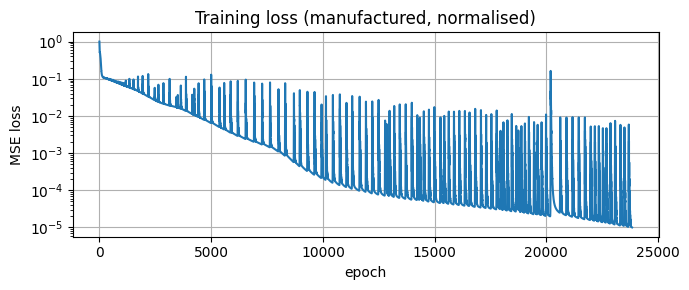

In [65]:
torch.manual_seed(42)
net_val   = Net(P.shape[0], N_tot_v)
opt_val   = torch.optim.Adam(net_val.parameters(), lr=1e-3)
loss_hist_v=[]; epoch_v=0; loss_v=1.0

print("Training POD-NN (manufactured, normalised)...")
while loss_v >= train_tol and epoch_v < epoch_max:
    epoch_v += 1
    opt_val.zero_grad()
    loss = loss_fn(net_val(x_tv), y_tv)
    loss_v = loss.item()
    #if epoch_v in lr_schedule: opt_val.param_groups[0]['lr'] = lr_schedule[epoch_v]
    loss.backward(); opt_val.step()
    loss_hist_v.append(loss_v)
    if epoch_v % 5000 == 0:
        print(f"  epoch {epoch_v:>7d}  loss {loss_v:.6e}")

print(f"Done — epoch {epoch_v}, loss {loss_v:.6e}")

plt.figure(figsize=(7, 3))
plt.semilogy(loss_hist_v)
plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.title('Training loss (manufactured, normalised)')
plt.grid(True); plt.tight_layout(); plt.show()

### 8.4 — Error vs exact solution: FOM floor vs POD-NN

In [66]:
def l2_vs_exact(u_num, u_strong, dofs, ref, fn):
    r = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
        geometry_utilities, mesh, mesh_geometric_data, dofs, ref, u_num, u_strong, fn)
    return r.error_l2, r.numeric_norm_l2

zero_su = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
    speed_x_strong_function)
zero_sp = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data,
    pressure_strong_function)

np.random.seed(99)
ts_val = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(30, P.shape[0]))

net_val.eval()
rows = []
print(f"{'mu0':>6} {'mu1':>6} | {'FOM_ux':>10} {'FOM_uy':>10} {'FOM_p':>10} | {'NN_ux':>10} {'NN_uy':>10} {'NN_p':>10}")
print('-'*88)

for mu in ts_val:
    # FOM
    fk   = solve_ns_manuf(mu)
    f_ux, f_uy, f_p = fk[0:speed_n_dofs], fk[speed_n_dofs:2*speed_n_dofs], fk[2*speed_n_dofs:]
    e_f_ux,_ = l2_vs_exact(f_ux, zero_su, speed_dofs_data, speed_reference_element_data, ux_exact_fn)
    e_f_uy,_ = l2_vs_exact(f_uy, zero_su, speed_dofs_data, speed_reference_element_data, uy_exact_fn)
    e_f_p, _ = l2_vs_exact(f_p,  zero_sp, pressure_dofs_data, pressure_reference_element_data, p_exact_fn)

    # POD-NN (with normalisation)
    mu_s  = np.float32(scale_input_v(mu))
    x_t   = torch.tensor(mu_s[None,:])
    with torch.no_grad():
        cn   = net_val(x_t).numpy()[0]
    coeff = unscale_output_v(cn)
    nn_fe = gb_v @ coeff
    n_ux, n_uy, n_p = nn_fe[0:speed_n_dofs], nn_fe[speed_n_dofs:2*speed_n_dofs], nn_fe[2*speed_n_dofs:]
    e_n_ux,_ = l2_vs_exact(n_ux, zero_su, speed_dofs_data, speed_reference_element_data, ux_exact_fn)
    e_n_uy,_ = l2_vs_exact(n_uy, zero_su, speed_dofs_data, speed_reference_element_data, uy_exact_fn)
    e_n_p, _ = l2_vs_exact(n_p,  zero_sp, pressure_dofs_data, pressure_reference_element_data, p_exact_fn)

    rows.append(dict(mu0=mu[0],mu1=mu[1],
                     e_fom_ux=e_f_ux,e_fom_uy=e_f_uy,e_fom_p=e_f_p,
                     e_nn_ux=e_n_ux, e_nn_uy=e_n_uy, e_nn_p=e_n_p))
    print(f"{mu[0]:6.3f} {mu[1]:6.3f} | {e_f_ux:10.3e} {e_f_uy:10.3e} {e_f_p:10.3e} | {e_n_ux:10.3e} {e_n_uy:10.3e} {e_n_p:10.3e}")

   mu0    mu1 |     FOM_ux     FOM_uy      FOM_p |      NN_ux      NN_uy       NN_p
----------------------------------------------------------------------------------------
 6.756  1.976 |  1.044e-04  1.012e-04  2.979e-02 |  3.454e-03  3.455e-03  2.991e-02
 8.272  1.063 |  1.041e-04  1.011e-04  3.362e-02 |  3.314e-03  3.315e-03  3.359e-02
 8.100  2.131 |  1.042e-04  1.011e-04  3.318e-02 |  2.672e-03  2.671e-03  3.424e-02
 3.046  1.093 |  1.066e-04  1.026e-04  2.153e-02 |  2.059e-03  2.060e-03  2.169e-02
 9.907  1.014 |  1.040e-04  1.011e-04  3.790e-02 |  8.106e-03  8.105e-03  3.988e-02
 7.721  2.494 |  1.042e-04  1.011e-04  3.221e-02 |  6.027e-03  6.026e-03  3.353e-02
 3.837  1.988 |  1.056e-04  1.019e-04  2.310e-02 |  6.316e-04  6.298e-04  2.334e-02
 9.297  1.791 |  1.041e-04  1.011e-04  3.629e-02 |  2.138e-03  2.139e-03  3.663e-02
 9.742  2.049 |  1.040e-04  1.011e-04  3.747e-02 |  2.077e-04  2.073e-04  3.757e-02
 1.027  2.627 |  1.243e-04  1.180e-04  1.826e-02 |  7.322e-03  7.320e-0